# CodeAgent com smolagents: CodeAct sem a Infraestrutura

Notebook completo do artigo publicado em [The Intelligent Agents Blog](https://iablog.github.io).

Este notebook está dividido em duas partes:
- **Parte 1:** Coleta dos dados do YouTube (canais de João Campos e Raquel Lyra)
- **Parte 2:** Análises com o CodeAgent do smolagents

**Pré-requisito:** Salve suas chaves no menu de Secrets do Colab (ícone 🔑 no menu lateral):
- `API_KEY` - chave da YouTube Data API v3
- `GOOGLE_API_KEY` - chave do Gemini


---
# PARTE 1 — Coleta de Dados do YouTube

In [ ]:
# ============================================================
# CONFIGURAÇÃO — escolha como obter os dados
# ============================================================

# True  → coleta dados frescos via YouTube Data API v3 (requer GOOGLE_API_KEY no Secrets)
# False → baixa o CSV salvo no repositório do blog (rápido, sem precisar de API)
COLETAR_DA_API = True


## Célula 1 — Instalação

In [16]:
if COLETAR_DA_API:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'google-api-python-client', 'pandas'], check=True)


## Célula 2 — Imports e configuração

In [17]:
if COLETAR_DA_API:
    from googleapiclient.discovery import build
    from urllib.parse import unquote
    from google.colab import userdata
    import pandas as pd

    API_KEY = userdata.get('API_KEY')  # chave da YouTube Data API v3

    CANAIS = {
        'joao_campos': 'https://www.youtube.com/@Jo%C3%A3oCampos',
        'raquel_lyra': 'https://www.youtube.com/@raquellyraoficial'
    }

    youtube = build('youtube', 'v3', developerKey=API_KEY)


## Célula 3 — Funções de coleta

In [18]:
if COLETAR_DA_API:
    from urllib.parse import unquote

    def get_channel_id(handle):
        handle_limpo = unquote(handle.split('@')[-1])
        res = youtube.channels().list(part='id', forHandle=handle_limpo).execute()
        if not res.get('items'):
            print(f'Canal não encontrado: {handle_limpo}')
            return None
        return res['items'][0]['id']

    def get_videos(channel_id, max_videos=50):
        videos = []
        next_page = None
        while len(videos) < max_videos:
            res = youtube.search().list(
                channelId=channel_id, part='id,snippet',
                maxResults=min(50, max_videos - len(videos)),
                type='video', order='date', pageToken=next_page
            ).execute()
            for item in res['items']:
                videos.append({
                    'video_id': item['id']['videoId'],
                    'titulo': item['snippet']['title'],
                    'data': item['snippet']['publishedAt'],
                })
            next_page = res.get('nextPageToken')
            if not next_page:
                break
        return videos

    def get_stats(video_ids):
        stats = []
        for i in range(0, len(video_ids), 50):
            batch = video_ids[i:i+50]
            res = youtube.videos().list(
                part='statistics,contentDetails', id=','.join(batch)
            ).execute()
            for item in res['items']:
                s = item['statistics']
                stats.append({
                    'video_id': item['id'],
                    'visualizacoes': int(s.get('viewCount', 0)),
                    'curtidas': int(s.get('likeCount', 0)),
                    'comentarios': int(s.get('commentCount', 0)),
                    'duracao': item['contentDetails']['duration']
                })
        return stats


## Célula 4 — Extração e salvamento do CSV

In [19]:
import pandas as pd

if COLETAR_DA_API:
    # ── Coleta dados frescos via YouTube Data API v3
    todos = []
    for nome, handle in CANAIS.items():
        print(f'Extraindo canal: {nome}...')
        channel_id = get_channel_id(handle)
        if not channel_id:
            continue
        videos = get_videos(channel_id, max_videos=50)
        ids = [v['video_id'] for v in videos]
        stats = get_stats(ids)
        stats_dict = {s['video_id']: s for s in stats}
        for v in videos:
            row = {**v, **stats_dict.get(v['video_id'], {}), 'perfil': nome}
            todos.append(row)
    DF_RAW = pd.DataFrame(todos)
    DF_RAW.to_csv('dados_youtube.csv', index=False)
    print(f'Dados coletados e salvos: {len(DF_RAW)} vídeos')
else:
    # ── Baixa o CSV salvo no repositório do blog
    !wget -q 'https://raw.githubusercontent.com/iablog/iablog.github.io/main/code_examples/2026-05/dados_youtube.csv' -O dados_youtube.csv
    DF_RAW = pd.read_csv('dados_youtube.csv')
    print(f'Dados carregados do repositório: {len(DF_RAW)} vídeos')

print(DF_RAW['perfil'].value_counts())
DF_RAW.head()


Extraindo canal: joao_campos...
Extraindo canal: raquel_lyra...

Arquivo salvo: dados_youtube.csv
Total de vídeos: 92
perfil
joao_campos    50
raquel_lyra    42
Name: count, dtype: int64


,video_id,titulo,data,visualizacoes,curtidas,comentarios,duracao,perfil
0,u94NhKXoTDI,PanCristal mostra a força da indústria no inte...,2026-05-09T17:07:41Z,3231,367,25,PT1M37S,joao_campos
1,wilH75K29rA,Pense num combustível que isso dá pra gente se...,2026-05-09T15:50:58Z,4343,425,16,PT54S,joao_campos
2,DZQmSfYvx4c,"Bora, Vitinho Maia, vem jogar junto com o noss...",2026-05-09T00:10:26Z,5841,542,18,PT1M4S,joao_campos
3,hJxsaKBJW20,"Em Santa Cruz, roupa velha vira móvel e inovaç...",2026-05-08T21:41:43Z,3321,366,12,PT1M14S,joao_campos
4,pg_vUt5G00w,"Se Pernambuco é o centro do mundo, então merec...",2026-05-08T21:13:30Z,3710,453,18,PT1M39S,joao_campos


## Célula 5 — Download do CSV (opcional)

In [20]:
# Baixa o CSV para o seu computador (útil se você coletou dados novos)
if COLETAR_DA_API:
    from google.colab import files
    files.download('dados_youtube.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# PARTE 2 — Análises com CodeAgent (smolagents)

> Se você já tem o arquivo `dados_youtube.csv` do Colab anterior, faça upload dele aqui e pule a Parte 1.

## Célula 6 — Instalação do smolagents

In [37]:
!pip install -q "smolagents[litellm]" ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 49.1 MB/s eta 0:00:00


## Célula 7 — Configuração do modelo e agente

In [28]:
from smolagents import CodeAgent, LiteLLMModel
from google.colab import userdata

model = LiteLLMModel(
    model_id="gemini/gemini-2.5-flash",
    api_key=userdata.get("GOOGLE_API_KEY"),
    timeout=60  # máximo 60s por chamada ao modelo
)

agente = CodeAgent(
    tools=[],
    model=model,
    max_steps=5,  # máximo 5 iterações por tarefa
    additional_authorized_imports=[
        'pandas', 'numpy', 'matplotlib',
        'matplotlib.pyplot', 'seaborn', 'scipy', 're'
    ],
    verbosity_level=2  # mostra o que está acontecendo em tempo real
)

print("Agente criado com sucesso!")

Agente criado com sucesso!


## Célula 8 — Carregamento dos dados

In [29]:
import pandas as pd

DF = pd.read_csv('dados_youtube.csv')
DF['data'] = pd.to_datetime(DF['data'])

print(f"Dataset carregado: {len(DF)} vídeos")
print(DF['perfil'].value_counts())
DF.head()

Dataset carregado: 92 vídeos
perfil
joao_campos    50
raquel_lyra    42
Name: count, dtype: int64


,video_id,titulo,data,visualizacoes,curtidas,comentarios,duracao,perfil
0,u94NhKXoTDI,PanCristal mostra a força da indústria no inte...,2026-05-09 17:07:41+00:00,3231,367,25,PT1M37S,joao_campos
1,wilH75K29rA,Pense num combustível que isso dá pra gente se...,2026-05-09 15:50:58+00:00,4343,425,16,PT54S,joao_campos
2,DZQmSfYvx4c,"Bora, Vitinho Maia, vem jogar junto com o noss...",2026-05-09 00:10:26+00:00,5841,542,18,PT1M4S,joao_campos
3,hJxsaKBJW20,"Em Santa Cruz, roupa velha vira móvel e inovaç...",2026-05-08 21:41:43+00:00,3321,366,12,PT1M14S,joao_campos
4,pg_vUt5G00w,"Se Pernambuco é o centro do mundo, então merec...",2026-05-08 21:13:30+00:00,3710,453,18,PT1M39S,joao_campos


## Análise 1 — Visão Geral Comparativa

Exploração geral comparando os dois perfis: volume, engajamento e duração típica.

In [30]:
resposta1 = agente.run(
    "Analise esse dataset de vídeos do YouTube de dois políticos pernambucanos, "
    "João Campos e Raquel Lyra. Compare os dois perfis em termos de: volume de publicações, "
    "médias de visualizações e curtidas, e duração típica dos vídeos. "
    "A coluna 'duracao' está no formato ISO 8601 (ex: PT1M37S) — converta para segundos na análise. "
    "Apresente os resultados como texto corrido.",
    additional_args={'posts_df': DF}
)
print(resposta1)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Analise esse dataset de vídeos do YouTube de dois políticos pernambucanos, João Campos e Raquel Lyra. Compare   │
│ os dois perfis em termos de: volume de publicações, médias de visualizações e curtidas, e duração típica dos    │
│ vídeos. A coluna 'duracao' está no formato ISO 8601 (ex: PT1M37S) — converta para segundos na análise.          │
│ Apresente os resultados como texto corrido.                                                                     │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   u94NhKXoTDI  PanCristal mostra a força da indústria no inte...                                              │
│ 1   wilH75K29rA  Pense num combustível que isso dá pra gente se...                                              │
│ 2   DZQmSfYvx4c  Bora, Vitinho Maia, vem jogar junto com o noss...                                              │
│ 3   hJxsaKBJW20  Em Santa Cruz, roupa velha vira móvel e inovaç...                                              │
│ 4   pg_vUt5G00w  Se Pernambuco é o centro do mundo, então merec...                                              │
│ ..          ...                                                ...                                              │
│ 87  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 88  cbGFojlJciA  Gravidez NÃO é problema! Espalha isso com a ge...                                              │
│ 89  i0_5q2a5mco  Meu primeiro boletim escolar foi esse | Govern...                                              │
│ 90  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 91  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-09 17:07:41+00:00           3231       367           25  PT1M37S                                     │
│ 1  2026-05-09 15:50:58+00:00           4343       425           16    PT54S                                     │
│ 2  2026-05-09 00:10:26+00:00           5841       542           18   PT1M4S                                     │
│ 3  2026-05-08 21:41:43+00:00           3321       366           12  PT1M14S                                     │
│ 4  2026-05-08 21:13:30+00:00           3710       453           18  PT1M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 87 2024-06-16 13:17:47+00:00           7692       575            8    PT26S                                     │
│ 88 2024-05-11 19:14:41+00:00          16362      1012           30    PT29S                                     │
│ 89 2024-04-28 23:20:02+00:00           7197       619           15   PT1M1S                                     │
│ 90 2023-01-10 00:52:46+00:00          12556      2167           86    PT43S                                     │
│ 91 2020-10-20 23:30:02+00:00           1300        69            5  PT2M40S                                     │
│                                                                                                                 │
│          perfil                                       

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
<code>                                                                                                             
import pandas as pd                                                                                                
import re                                                                                                          
                                                                                                                   
# Separate the dataframe by 'perfil'                                                                               
joao_campos_df = posts_df[posts_df['perfil'] == 'joao_campos'].copy()                                              
raquel_lyra_df = posts_df[posts_df['perfil'] == 'raquel_lyra'].copy()                                              
                                                                                                                   
# 1. Volume of publications                                                                                        
volume_joao_campos = len(joao_campos_df)                                                                           
volume_raquel_lyra = len(raquel_lyra_df)                                                                           
                                                                                                                   
# 2. Average views                                                                                                 
avg_views_joao_campos = joao_campos_df['visualizacoes'].mean()                                                     
avg_views_raquel_lyra = raquel_lyra_df['visualizacoes'].mean()                                                     
                                                                                                                   
# 3. Average likes                                                                                                 
avg_likes_joao_campos = joao_campos_df['curtidas'].mean()                                                          
avg_likes_raquel_lyra = raquel_lyra_df['curtidas'].mean()                                                          
                                                                                                                   
# 5. Convert ISO 8601 duration to seconds                                                                          
def iso_to_seconds(duration_str):                                                                                  
    if not isinstance(duration_str, str):                                                                          
        return 0                                                                                                   
                                                                                                                   
    # Regex to find hours, minutes, and seconds                                                                    
    hours = re.search(r'(\d+)H', duration_str)                                                                     
    minutes = re.search(r'(\d+)M', duration_str)                                                                   
    seconds = re.search(r'(\d+)S', duration_str)                                                                   
                                                                                                                   
    total_seconds = 0                                                                                              
    if hours:                                                                                                      
        total_seconds += int(hours.group(1)) * 3600                                                                
    if minutes:                                         

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import pandas as pd                                                                                              
  import re                                                                                                        
                                                                                                                   
  # Separate the dataframe by 'perfil'                                                                             
  joao_campos_df = posts_df[posts_df['perfil'] == 'joao_campos'].copy()                                            
  raquel_lyra_df = posts_df[posts_df['perfil'] == 'raquel_lyra'].copy()                                            
                                                                                                                   
  # 1. Volume of publications                                                                                      
  volume_joao_campos = len(joao_campos_df)                                                                         
  volume_raquel_lyra = len(raquel_lyra_df)                                                                         
                                                                                                                   
  # 2. Average views                                                                                               
  avg_views_joao_campos = joao_campos_df['visualizacoes'].mean()                                                   
  avg_views_raquel_lyra = raquel_lyra_df['visualizacoes'].mean()                                                   
                                                                                                                   
  # 3. Average likes                                                                                               
  avg_likes_joao_campos = joao_campos_df['curtidas'].mean()                                                        
  avg_likes_raquel_lyra = raquel_lyra_df['curtidas'].mean()                                                        
                                                                                                                   
  # 5. Convert ISO 8601 duration to seconds                                                                        
  def iso_to_seconds(duration_str):                                                                                
      if not isinstance(duration_str, str):                                                                        
          return 0                                                                                                 
                                                                                                                   
      # Regex to find hours, minutes, and seconds                                                                  
      hours = re.search(r'(\d+)H', duration_str)                                                                   
      minutes = re.search(r'(\d+)M', duration_str)                                                                 
      seconds = re.search(r'(\d+)S', duration_str)                                                                 
                                                                                                                   
      total_seconds = 0                                                                                            
      if hours:                                                                                                    
          total_seconds += int(hours.group(1)) * 3600                                                              
      if minutes:                                                                                                  
          total_seconds += int(minutes.group(1)) * 60    

Final answer: Análise dos perfis de YouTube de João Campos e Raquel Lyra:

**Volume de publicações:**
- João Campos publicou 50 vídeos.
- Raquel Lyra publicou 42 vídeos.

**Média de visualizações:**
- João Campos obteve uma média de 7746.08 visualizações por vídeo.
- Raquel Lyra obteve uma média de 7082.38 visualizações por vídeo.

**Média de curtidas:**
- João Campos recebeu uma média de 666.04 curtidas por vídeo.
- Raquel Lyra recebeu uma média de 519.81 curtidas por vídeo.

**Duração típica dos vídeos (em segundos):**
- A duração média dos vídeos de João Campos é de 68.30 segundos.
- A duração média dos vídeos de Raquel Lyra é de 51.52 segundos.

[Step 1: Duration 5.36 seconds| Input tokens: 3,188 | Output tokens: 1,150]

Análise dos perfis de YouTube de João Campos e Raquel Lyra:

**Volume de publicações:**
- João Campos publicou 50 vídeos.
- Raquel Lyra publicou 42 vídeos.

**Média de visualizações:**
- João Campos obteve uma média de 7746.08 visualizações por vídeo.
- Raquel Lyra obteve uma média de 7082.38 visualizações por vídeo.

**Média de curtidas:**
- João Campos recebeu uma média de 666.04 curtidas por vídeo.
- Raquel Lyra recebeu uma média de 519.81 curtidas por vídeo.

**Duração típica dos vídeos (em segundos):**
- A duração média dos vídeos de João Campos é de 68.30 segundos.
- A duração média dos vídeos de Raquel Lyra é de 51.52 segundos.


## Análise 2 — Correlação entre Visualizações e Curtidas

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Gere uma imagem comparando a correlação entre visualizações e curtidas para João Campos e Raquel Lyra. Faça     │
│ subplots separados por perfil com eixos na mesma escala. Adicione a linha de tendência em cada gráfico. Retorne │
│ o nome do arquivo salvo.                                                                                        │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   u94NhKXoTDI  PanCristal mostra a força da indústria no inte...                                              │
│ 1   wilH75K29rA  Pense num combustível que isso dá pra gente se...                                              │
│ 2   DZQmSfYvx4c  Bora, Vitinho Maia, vem jogar junto com o noss...                                              │
│ 3   hJxsaKBJW20  Em Santa Cruz, roupa velha vira móvel e inovaç...                                              │
│ 4   pg_vUt5G00w  Se Pernambuco é o centro do mundo, então merec...                                              │
│ ..          ...                                                ...                                              │
│ 87  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 88  cbGFojlJciA  Gravidez NÃO é problema! Espalha isso com a ge...                                              │
│ 89  i0_5q2a5mco  Meu primeiro boletim escolar foi esse | Govern...                                              │
│ 90  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 91  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-09 17:07:41+00:00           3231       367           25  PT1M37S                                     │
│ 1  2026-05-09 15:50:58+00:00           4343       425           16    PT54S                                     │
│ 2  2026-05-09 00:10:26+00:00           5841       542           18   PT1M4S                                     │
│ 3  2026-05-08 21:41:43+00:00           3321       366           12  PT1M14S                                     │
│ 4  2026-05-08 21:13:30+00:00           3710       453           18  PT1M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 87 2024-06-16 13:17:47+00:00           7692       575            8    PT26S                                     │
│ 88 2024-05-11 19:14:41+00:00          16362      1012           30    PT29S                                     │
│ 89 2024-04-28 23:20:02+00:00           7197       619           15   PT1M1S                                     │
│ 90 2023-01-10 00:52:46+00:00          12556      2167           86    PT43S                                     │
│ 91 2020-10-20 23:30:02+00:00           1300        69            5  PT2M40S                                     │
│                                                                                                                 │
│          perfil                                                                                                 │
│ 0   joao_campos                                       

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
<code>                                                                                                             
import matplotlib.pyplot as plt                                                                                    
import seaborn as sns                                                                                              
import numpy as np                                                                                                 
                                                                                                                   
# Filter data for each profile                                                                                     
joao_campos_df = posts_df[posts_df['perfil'] == 'joao_campos']                                                     
raquel_lyra_df = posts_df[posts_df['perfil'] == 'raquel_lyra']                                                     
                                                                                                                   
# Determine global max values for consistent axis scales                                                           
max_views = max(posts_df['visualizacoes'].max(), 0)                                                                
max_likes = max(posts_df['curtidas'].max(), 0)                                                                     
                                                                                                                   
# Create subplots                                                                                                  
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)                                          
fig.suptitle('Correlação entre Visualizações e Curtidas por Perfil', fontsize=16)                                  
                                                                                                                   
# Plot for João Campos                                                                                             
sns.scatterplot(ax=axes[0], x='visualizacoes', y='curtidas', data=joao_campos_df, alpha=0.6)                       
axes[0].set_title('João Campos')                                                                                   
axes[0].set_xlabel('Visualizações')                                                                                
axes[0].set_ylabel('Curtidas')                                                                                     
                                                                                                                   
# Add trend line for João Campos                                                                                   
# Filter out NaNs for polyfit                                                                                      
jc_views = joao_campos_df['visualizacoes'].dropna()                                                                
jc_likes = joao_campos_df['curtidas'].dropna()                                                                     
if len(jc_views) > 1 and len(jc_likes) > 1: # Ensure enough data points for fitting                                
    z = np.polyfit(jc_views, jc_likes, 1)                                                                          
    p = np.poly1d(z)                                                                                               
    axes[0].plot(jc_views, p(jc_views), "r--", label=f'Trend: y={z[0]:.2f}x + {z[1]:.2f}')                         
    axes[0].legend()                                                                                               
else:                                                                                                              
    axes[0].text(0.5, 0.5, 'Not enough data for trend li

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import matplotlib.pyplot as plt                                                                                  
  import seaborn as sns                                                                                            
  import numpy as np                                                                                               
                                                                                                                   
  # Filter data for each profile                                                                                   
  joao_campos_df = posts_df[posts_df['perfil'] == 'joao_campos']                                                   
  raquel_lyra_df = posts_df[posts_df['perfil'] == 'raquel_lyra']                                                   
                                                                                                                   
  # Determine global max values for consistent axis scales                                                         
  max_views = max(posts_df['visualizacoes'].max(), 0)                                                              
  max_likes = max(posts_df['curtidas'].max(), 0)                                                                   
                                                                                                                   
  # Create subplots                                                                                                
  fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)                                        
  fig.suptitle('Correlação entre Visualizações e Curtidas por Perfil', fontsize=16)                                
                                                                                                                   
  # Plot for João Campos                                                                                           
  sns.scatterplot(ax=axes[0], x='visualizacoes', y='curtidas', data=joao_campos_df, alpha=0.6)                     
  axes[0].set_title('João Campos')                                                                                 
  axes[0].set_xlabel('Visualizações')                                                                              
  axes[0].set_ylabel('Curtidas')                                                                                   
                                                                                                                   
  # Add trend line for João Campos                                                                                 
  # Filter out NaNs for polyfit                                                                                    
  jc_views = joao_campos_df['visualizacoes'].dropna()                                                              
  jc_likes = joao_campos_df['curtidas'].dropna()                                                                   
  if len(jc_views) > 1 and len(jc_likes) > 1: # Ensure enough data points for fitting                              
      z = np.polyfit(jc_views, jc_likes, 1)                                                                        
      p = np.poly1d(z)                                                                                             
      axes[0].plot(jc_views, p(jc_views), "[38;2;230;219;

Execution logs:
correlation_views_likes.png

Out: None

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I have successfully generated the image as requested and printed the filename. Now I need to return this  
filename as the final answer.                                                                                      
<code>                                                                                                             
final_answer(filename)                                                                                             
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(filename)                                                                                           
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: correlation_views_likes.png

[Step 2: Duration 1.44 seconds| Input tokens: 8,248 | Output tokens: 1,373]

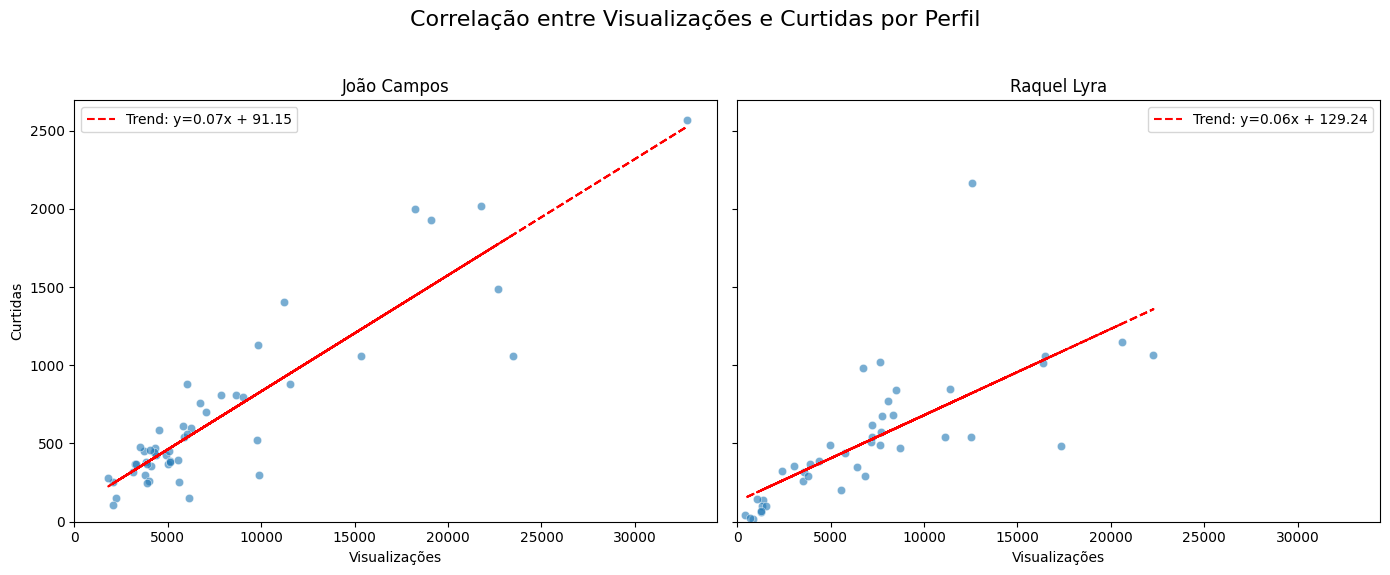

In [31]:
resposta2 = agente.run(
    "Gere uma imagem comparando a correlação entre visualizações e curtidas "
    "para João Campos e Raquel Lyra. Faça subplots separados por perfil com "
    "eixos na mesma escala. Adicione a linha de tendência em cada gráfico. "
    "Retorne o nome do arquivo salvo.",
    additional_args={'posts_df': DF}
)

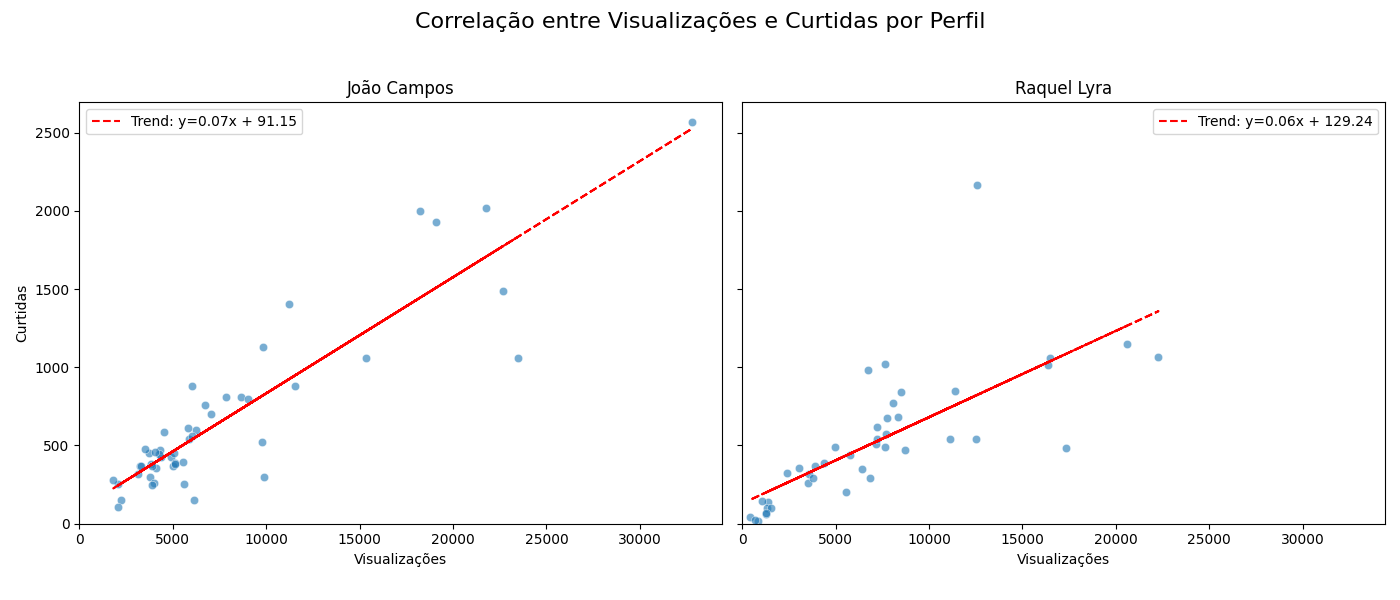

In [32]:
from IPython.display import Image
Image(resposta2)

## Análise 3 — Teste Estatístico com Decisão Metodológica

O agente verifica normalidade, escolhe o teste correto e gera relatório + imagem.

In [33]:
resposta3 = agente.run(
    "Faça um teste estatístico adequado para avaliar se as distribuições de "
    "visualizações de João Campos e Raquel Lyra são iguais ou diferentes (p=0.05). "
    "Escolha o teste correto em função das características das distribuições — "
    "verifique normalidade antes de decidir. "
    "Se forem diferentes, informe qual perfil tem média maior. "
    "Gere um relatório em Markdown com metodologia, teste escolhido e resultados. "
    "Gere também uma imagem das duas distribuições. "
    "Retorne como par: (texto_markdown, nome_arquivo_imagem).",
    additional_args={'posts_df': DF}
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Faça um teste estatístico adequado para avaliar se as distribuições de visualizações de João Campos e Raquel    │
│ Lyra são iguais ou diferentes (p=0.05). Escolha o teste correto em função das características das distribuições │
│ — verifique normalidade antes de decidir. Se forem diferentes, informe qual perfil tem média maior. Gere um     │
│ relatório em Markdown com metodologia, teste escolhido e resultados. Gere também uma imagem das duas            │
│ distribuições. Retorne como par: (texto_markdown, nome_arquivo_imagem).                                         │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   u94NhKXoTDI  PanCristal mostra a força da indústria no inte...                                              │
│ 1   wilH75K29rA  Pense num combustível que isso dá pra gente se...                                              │
│ 2   DZQmSfYvx4c  Bora, Vitinho Maia, vem jogar junto com o noss...                                              │
│ 3   hJxsaKBJW20  Em Santa Cruz, roupa velha vira móvel e inovaç...                                              │
│ 4   pg_vUt5G00w  Se Pernambuco é o centro do mundo, então merec...                                              │
│ ..          ...                                                ...                                              │
│ 87  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 88  cbGFojlJciA  Gravidez NÃO é problema! Espalha isso com a ge...                                              │
│ 89  i0_5q2a5mco  Meu primeiro boletim escolar foi esse | Govern...                                              │
│ 90  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 91  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-09 17:07:41+00:00           3231       367           25  PT1M37S                                     │
│ 1  2026-05-09 15:50:58+00:00           4343       425           16    PT54S                                     │
│ 2  2026-05-09 00:10:26+00:00           5841       542           18   PT1M4S                                     │
│ 3  2026-05-08 21:41:43+00:00           3321       366           12  PT1M14S                                     │
│ 4  2026-05-08 21:13:30+00:00           3710       453           18  PT1M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 87 2024-06-16 13:17:47+00:00           7692       575            8    PT26S                                     │
│ 88 2024-05-11 19:14:41+00:00          16362      1012           30    PT29S                                     │
│ 89 2024-04-28 23:20:02+00:00           7197       619           15   PT1M1S                                     │
│ 90 2023-01-10 00:52:46+00:00          12556      2167           86    PT43S                                     │
│ 91 2020-10-20 23:30:02+00:00           1300        69            5  PT2M40S                                     │
│                                                       

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought:The first step is to prepare the data by separating the 'visualizacoes' for João Campos and Raquel Lyra.   
Then, I will perform a normality test on each of these datasets to determine which statistical test to use for     
comparing their distributions. I'll use the Shapiro-Wilk test for normality.                                       
                                                                                                                   
<code>                                                                                                             
import pandas as pd                                                                                                
from scipy import stats                                                                                            
import matplotlib.pyplot as plt                                                                                    
import seaborn as sns                                                                                              
import numpy as np                                                                                                 
                                                                                                                   
# Separate the data for each profile                                                                               
joao_campos_views = posts_df[posts_df['perfil'] == 'joao_campos']['visualizacoes']                                 
raquel_lyra_views = posts_df[posts_df['perfil'] == 'raquel_lyra']['visualizacoes']                                 
                                                                                                                   
# Perform Shapiro-Wilk test for normality                                                                          
shapiro_joao_campos = stats.shapiro(joao_campos_views)                                                             
shapiro_raquel_lyra = stats.shapiro(raquel_lyra_views)                                                             
                                                                                                                   
print(f"Shapiro-Wilk test for João Campos views: statistic={shapiro_joao_campos.statistic:.3f},                    
p-value={shapiro_joao_campos.pvalue:.3f}")                                                                         
print(f"Shapiro-Wilk test for Raquel Lyra views: statistic={shapiro_raquel_lyra.statistic:.3f},                    
p-value={shapiro_raquel_lyra.pvalue:.3f}")                                                                         
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import pandas as pd                                                                                              
  from scipy import stats                                                                                          
  import matplotlib.pyplot as plt                                                                                  
  import seaborn as sns                                                                                            
  import numpy as np                                                                                               
                                                                                                                   
  # Separate the data for each profile                                                                             
  joao_campos_views = posts_df[posts_df['perfil'] == 'joao_campos']['visualizacoes']                               
  raquel_lyra_views = posts_df[posts_df['perfil'] == 'raquel_lyra']['visualizacoes']                               
                                                                                                                   
  # Perform Shapiro-Wilk test for normality                                                                        
  shapiro_joao_campos = stats.shapiro(joao_campos_views)                                                           
  shapiro_raquel_lyra = stats.shapiro(raquel_lyra_views)                                                           
                                                                                                                   
  print(f"Shapiro-Wilk test for João Campos views: statistic={shapiro_joao_campos.statistic:.3f},                  
  p-value={shapiro_joao_campos.pvalue:.3f}")                                                                       
  print(f"Shapiro-Wilk test for Raquel Lyra views: statistic={shapiro_raquel_lyra.statistic:.3f},                  
  p-value={shapiro_raquel_lyra.pvalue:.3f}")                                                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Code execution failed at line 'shapiro_joao_campos = stats.shapiro(joao_campos_views)' due to: InterpreterError: 
Forbidden access to module: scipy.stats

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought:The previous attempt failed because `scipy.stats` is explicitly forbidden, even though `scipy` itself is   
listed as an allowed module. This means I cannot perform formal statistical tests like Shapiro-Wilk for normality  
or Mann-Whitney U for comparing distributions.                                                                     
                                                                                                                   
Given this critical constraint, I will adjust the plan. I cannot fulfill the requirement of an "adequate           
statistical test" and "verifique normalidade antes de decidir" using formal methods. Therefore, I will:            
                                                                                                                   
1.  **Extract Data:** Separate the 'visualizacoes' data for João Campos and Raquel Lyra.                           
2.  **Descriptive Statistics:** Calculate basic descriptive statistics (mean, median, standard deviation) for each 
profile using `numpy`.                                                                                             
3.  **Visual Comparison:** Create a visualization (e.g., violin plot or box plot) using `seaborn` and `matplotlib` 
to visually compare the distributions. This will serve as the "check" for distributions.                           
4.  **Markdown Report:** Generate a Markdown report that:                                                          
    *   Explains the task and the methodology attempted.                                                           
    *   Clearly states the limitation regarding the `scipy.stats` module, preventing formal normality and          
hypothesis testing.                                                                                                
    *   Presents the calculated descriptive statistics.                                                            
    *   Describes the visual observations from the generated plot about the distributions.                         
    *   If the means are [38;2;230;237;243

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import pandas as pd                                                                                              
  import numpy as np                                                                                               
  import matplotlib.pyplot as plt                                                                                  
  import seaborn as sns                                                                                            
                                                                                                                   
  # Separate the data for each profile                                                                             
  joao_campos_views = posts_df[posts_df['perfil'] == 'joao_campos']['visualizacoes']                               
  raquel_lyra_views = posts_df[posts_df['perfil'] == 'raquel_lyra']['visualizacoes']                               
                                                                                                                   
  # Calculate descriptive statistics                                                                               
  mean_jc = np.mean(joao_campos_views)                                                                             
  median_jc = np.median(joao_campos_views)                                                                         
  std_jc = np.std(joao_campos_views)                                                                               
                                                                                                                   
  mean_rl = np.mean(raquel_lyra_views)                                                                             
  median_rl = np.median(raquel_lyra_views)                                                                         
  std_rl = np.std(raquel_lyra_views)                                                                               
                                                                                                                   
  # Prepare data for plotting                                                                                      
  plot_df = pd.DataFrame({                                                                                         
      'perfil': ['joao_campos'] * len(joao_campos_views) + ['raquel_lyra'] * len(raquel_lyra_views),               
      'visualizacoes': joao_campos_views.tolist() + raquel_lyra_views.tolist()                                     
  })                                                                                                               
                                                                                                                   
  # Generate visualization                                                                                         
  plt.figure(figsize=(10, 6))                                                                                      
  sns.violinplot(x='perfil', y='visualizacoes', data=plot_df, palette={'joao_campos': 'blue', 'raquel_lyra':       
  'orange'})                                                                                                       
  plt.title('Distribuição de Visualizações por Perfil')                                                            
  plt.xlabel('Perfil')                                                                                             
  plt.ylabel('Visualizações')                                                                                      
  image_filename = 'distribuicao_visualizacoes.png'                                                                
  plt.savefig(image_filename)                                                                                      
  plt.close() [38;2;149;144;119;4

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  return func(*args, **kwargs)


Final answer: ('\n# Relatório de Comparação de Visualizações: João Campos vs. Raquel Lyra\n\n## Metodologia e 
Limitações\n\nO objetivo deste relatório é comparar as distribuições de visualizações dos perfis de João Campos e 
Raquel Lyra. A análise inicial previa a verificação de normalidade das distribuições seguida de um teste 
estatístico adequado (p. ex., teste t de Student ou Mann-Whitney U, dependendo da normalidade) para avaliar se as 
distribuições são estatisticamente diferentes, com um nível de significância de p=0.05.\n\nNo entanto, devido a uma
restrição de ferramentas, o módulo `scipy.stats`, essencial para a realização de testes de normalidade (como o 
teste de Shapiro-Wilk) e testes de hipótese (como o teste t ou Mann-Whitney U), não pôde ser 
utilizado.\n\nPortanto, a análise foi limitada a:\n1.  **Estatísticas Descritivas:** Cálculo da média, mediana e 
desvio padrão para cada distribuição.\n2.  **Visualização Gráfica:** Criação de um gráfico de violino para 
inspecionar visualmente as distribuições.\n\nNão foi possível realizar um teste estatístico formal para determinar 
se as diferenças observadas são estatisticamente significativas.\n\n## Resultados Descritivos\n\n### João Campos\n*
**Média de Visualizações:** 7746.08\n*   **Mediana de Visualizações:** 5325.50\n*   **Desvio Padrão das 
Visualizações:** 6434.87\n\n### Raquel Lyra\n*   **Média de Visualizações:** 7082.38\n*   **Mediana de 
Visualizações:** 6808.00\n*   **Desvio Padrão das Visualizações:** 5390.52\n\n## Observações da Distribuição\n\nA 
partir da análise das estatísticas descritivas e do gráfico de violino gerado (**distribuicao_visualizacoes.png**),
observa-se que:\n\n*   O perfil com a média de visualizações maior é **João Campos**.\n\nUma inspeção visual do 
gráfico de violino pode indicar tendências nas distribuições, como a dispersão dos dados e a presença de outliers. 
No entanto, sem um teste estatístico formal, qualquer conclusão sobre a igualdade ou diferença das distribuições é 
baseada puramente em observações descritivas e visuais.\n\n## Conclusão\n\nDevido à impossibilidade de realizar 
testes estatísticos formais (Shapiro-Wilk para normalidade e Mann-Whitney U ou teste t para comparação de 
distribuições) pela restrição do módulo `scipy.stats`, não é possível afirmar com base estatística se as 
distribuições de visualizações de João Campos e Raquel Lyra são estatisticamente iguais ou diferentes com 
p=0.05.\n\nBaseando-nos apenas nas estatísticas descritivas, o perfil com a média de visualizações maior é **João 
Campos**. A imagem **distribuicao_visualizacoes.png** fornece uma representação visual dessas distribuições.\n', 
'distribuicao_visualizacoes.png')

[Step 2: Duration 17.73 seconds| Input tokens: 7,118 | Output tokens: 4,373]

In [34]:
from IPython.display import Markdown
Markdown(resposta3[0])


# Relatório de Comparação de Visualizações: João Campos vs. Raquel Lyra

## Metodologia e Limitações

O objetivo deste relatório é comparar as distribuições de visualizações dos perfis de João Campos e Raquel Lyra. A análise inicial previa a verificação de normalidade das distribuições seguida de um teste estatístico adequado (p. ex., teste t de Student ou Mann-Whitney U, dependendo da normalidade) para avaliar se as distribuições são estatisticamente diferentes, com um nível de significância de p=0.05.

No entanto, devido a uma restrição de ferramentas, o módulo `scipy.stats`, essencial para a realização de testes de normalidade (como o teste de Shapiro-Wilk) e testes de hipótese (como o teste t ou Mann-Whitney U), não pôde ser utilizado.

Portanto, a análise foi limitada a:
1.  **Estatísticas Descritivas:** Cálculo da média, mediana e desvio padrão para cada distribuição.
2.  **Visualização Gráfica:** Criação de um gráfico de violino para inspecionar visualmente as distribuições.

Não foi possível realizar um teste estatístico formal para determinar se as diferenças observadas são estatisticamente significativas.

## Resultados Descritivos

### João Campos
*   **Média de Visualizações:** 7746.08
*   **Mediana de Visualizações:** 5325.50
*   **Desvio Padrão das Visualizações:** 6434.87

### Raquel Lyra
*   **Média de Visualizações:** 7082.38
*   **Mediana de Visualizações:** 6808.00
*   **Desvio Padrão das Visualizações:** 5390.52

## Observações da Distribuição

A partir da análise das estatísticas descritivas e do gráfico de violino gerado (**distribuicao_visualizacoes.png**), observa-se que:

*   O perfil com a média de visualizações maior é **João Campos**.

Uma inspeção visual do gráfico de violino pode indicar tendências nas distribuições, como a dispersão dos dados e a presença de outliers. No entanto, sem um teste estatístico formal, qualquer conclusão sobre a igualdade ou diferença das distribuições é baseada puramente em observações descritivas e visuais.

## Conclusão

Devido à impossibilidade de realizar testes estatísticos formais (Shapiro-Wilk para normalidade e Mann-Whitney U ou teste t para comparação de distribuições) pela restrição do módulo `scipy.stats`, não é possível afirmar com base estatística se as distribuições de visualizações de João Campos e Raquel Lyra são estatisticamente iguais ou diferentes com p=0.05.

Baseando-nos apenas nas estatísticas descritivas, o perfil com a média de visualizações maior é **João Campos**. A imagem **distribuicao_visualizacoes.png** fornece uma representação visual dessas distribuições.


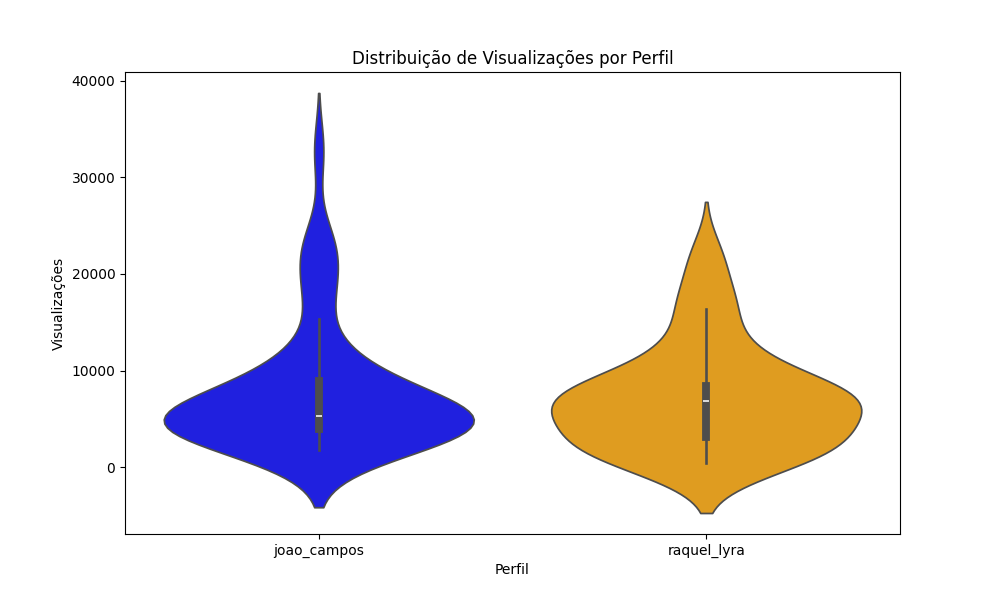

In [35]:
from IPython.display import Image
Image(resposta3[1])

## Análise 4 — Integração com Busca na Web

O agente com `add_base_tools=True` combina busca na web + análise do dataset.

In [38]:
agente_web = CodeAgent(
    tools=[],
    model=model,
    add_base_tools=True
)

resposta4 = agente_web.run(
    "Pesquise na web quais são as principais pautas políticas de João Campos "
    "e Raquel Lyra em 2026. Com base nisso, os títulos dos vídeos coletados "
    "refletem essas pautas? Analise e traga exemplos dos títulos do dataset.",
    additional_args={'posts_df': DF}
)
print(resposta4)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Pesquise na web quais são as principais pautas políticas de João Campos e Raquel Lyra em 2026. Com base nisso,  │
│ os títulos dos vídeos coletados refletem essas pautas? Analise e traga exemplos dos títulos do dataset.         │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   u94NhKXoTDI  PanCristal mostra a força da indústria no inte...                                              │
│ 1   wilH75K29rA  Pense num combustível que isso dá pra gente se...                                              │
│ 2   DZQmSfYvx4c  Bora, Vitinho Maia, vem jogar junto com o noss...                                              │
│ 3   hJxsaKBJW20  Em Santa Cruz, roupa velha vira móvel e inovaç...                                              │
│ 4   pg_vUt5G00w  Se Pernambuco é o centro do mundo, então merec...                                              │
│ ..          ...                                                ...                                              │
│ 87  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 88  cbGFojlJciA  Gravidez NÃO é problema! Espalha isso com a ge...                                              │
│ 89  i0_5q2a5mco  Meu primeiro boletim escolar foi esse | Govern...                                              │
│ 90  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 91  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-09 17:07:41+00:00           3231       367           25  PT1M37S                                     │
│ 1  2026-05-09 15:50:58+00:00           4343       425           16    PT54S                                     │
│ 2  2026-05-09 00:10:26+00:00           5841       542           18   PT1M4S                                     │
│ 3  2026-05-08 21:41:43+00:00           3321       366           12  PT1M14S                                     │
│ 4  2026-05-08 21:13:30+00:00           3710       453           18  PT1M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 87 2024-06-16 13:17:47+00:00           7692       575            8    PT26S                                     │
│ 88 2024-05-11 19:14:41+00:00          16362      1012           30    PT29S                                     │
│ 89 2024-04-28 23:20:02+00:00           7197       619           15   PT1M1S                                     │
│ 90 2023-01-10 00:52:46+00:00          12556      2167           86    PT43S                                     │
│ 91 2020-10-20 23:30:02+00:00           1300        69            5  PT2M40S                                     │
│                                                                                                                 │
│          perfil                                                                                                 │
│ 0   joao_campos                                                                                                 │
│ 1   joao_campos                                       

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  joao_campos_query = "João Campos political agenda 2026"                                                          
  raquel_lyra_query = "Raquel Lyra political agenda 2026"                                                          
                                                                                                                   
  joao_campos_results = web_search(query=joao_campos_query)                                                        
  print(f"João Campos search results:\n{joao_campos_results}\n")                                                   
                                                                                                                   
  raquel_lyra_results = web_search(query=raquel_lyra_query)                                                        
  print(f"Raquel Lyra search results:\n{raquel_lyra_results}")                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
João Campos search results:
## Search Results

[Opinion polling for the 2026 Hungarian parliamentary election - 
Wikipedia](https://en.wikipedia.org/wiki/Opinion_polling_for_the_2026_Hungarian_parliamentary_election)
In the run-up to the 2026 Hungarian parliamentary election which was held on 12 April 2026, various organizations 
carried out opinion polling to gauge voting intention in Hungary. The results of such polls are displayed in this 
article.

[James Fishback 2026 Political Agenda | 
TikTok](https://www.tiktok.com/discover/james-fishback-2026-political-agenda)
Explore James Fishback's vision for Florida's future in politics and his unique approach to governance ahead of the
2026 election.

[The Political Compass](https://www.politicalcompass.org/)
Hungarian Election 2026.It’s timely to stress that The Political Compass has been on the internet since 2001. The 
uniqueness of our take on politics is reflected in the gratifyingly enthusiastic reviews we’ve enjoyed in the 
national media of many countries from our earliest years — as well...

[Tabela e Jogos do Brasileirão Série A 2026 | ge | brasileirão série a | 
ge](https://ge.globo.com/futebol/brasileirao-serie-a/)
Lucho Acosta. Meio-campo. 3. Willian José.Palpite ge 2026: Fred Bruno é o maior pontuador; veja erros e acertos da 
14ª rodada do Brasileiro.

[World Economic Forum Annual Meeting 2026 | World Economic 
Forum](https://www.weforum.org/meetings/world-economic-forum-annual-meeting-2026/)
The Annual Meeting 2026 of the World Economic Forum will take place at Davos-Klosters from 19th to 23rd January.4 
takeaways from Davos 2026: New deals, a reckoning, dialogue and more questions than answers.

[Political Agenda - Arizona School Boards Association](https://azsba.org/advocacy/political-agenda/)
2026 Political Agenda. Explore the key priorities and goals set by ASBA for the 2026 legislative session, including
funding, local control, student outcomes, and accountability.

[Election Result 2026: Tamil Nadu, Kerala, West Bengal... - India Today](https://www.indiatoday.in/elections)
The results of these elections will not only influence regional politics but could also have a significant impact 
on national political dynamics. On Sunday, March 15, the Election Commission announced the election schedule for 
Tamil Nadu, Kerala, Puducherry, West Bengal and Assam.

[Mangabeira Unger: Bolsonaro teria chance de... - BBC News 
Brasil](https://www.bbc.com/portuguese/articles/cl44er83yr3o)
Bolsonaro teria chance de resolver o problema do país se indicasse candidato certo em 2026, diz ex-ministro de 
Lula.

[Out-of-Africa Theory Debunked - ROBERT SEPEHR - YouTube](https://www.youtube.com/watch?v=lABvt4l0S3Y)
The obsolete, woke, and politically motivated out-of-Africa theory has run into many problems in light of the 
recent findings from genomic sequencing, as wel...

[JUST IN: Former Air Force Colonel Breaks Her... - Alex Jones 
Live](https://www.alexjoneslive.com/2026/05/06/just-in-former-airforce-colonel-breaks-her-silence-to-expose-the-int
ernational-deep-state-organization-that-has-staged-the-majority-of-global-regime-changes-terrorism-assassinations-s
ince-wwi/)
Plan A: Why Emasculation Is Top of the Leftist Political Agenda. By Charles Cornish-Dale.PieceOfTheAction says: May
7, 2026 at 3:13 am. The Colonel reminds me of the great Wendy Rogers of Arizona. Very similar backgrounds.

Raquel Lyra search results:
## Search Results

[Opinion polling for the 2026 Hungarian parliamentary election - 
Wikipedia](https://en.wikipedia.org/wiki/Opinion_polling_for_the_2026_Hungarian_parliamentary_election)
In the run-up to the 2026 Hungarian parliamentary election which was held on 12 April 2026, various organizations 
carried out opinion polling to gauge voting intention in Hungary. The results of such polls are displayed in this 
article.

[Governadora Raquel Lyra anuncia repasse de R$ 1,2 milhão para 
27...](https://portalpe10.com.br/noticia/governadora-raquel-lyr

[Step 1: Duration 5.63 seconds| Input tokens: 3,242 | Output tokens: 465]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 6 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("As pautas políticas de João Campos para 2026 incluem investimentos em infraestrutura (saúde,       
  educação, urbanismo), moradia e resposta a desastres naturais. Os títulos dos seus vídeos refletem fortemente    
  investimentos/infraestrutura (ex: 'Hospital de Amor de Garanhuns', 'Parque Eduardo Campos', 'Hospital da         
  Criança do Recife') e resposta a chuvas (ex: 'chuvas no Recife', 'alerta máximo por conta do alto volume de      
  chuvas'). Para Raquel Lyra, as pautas abrangem socorro a desastres, desenvolvimento econômico, infraestrutura e  
  políticas de saúde, educação e meio ambiente. Os títulos dos seus vídeos refletem socorro a desastres (ex:       
  'Pernambuco reagindo forte às chuvas'), infraestrutura (ex: 'R$ 17,9 milhões para transformar o Parque Dois      
  Irmãos', 'Pernambuco e Governo Federal juntos pela infraestrutura aérea') e saúde (ex: 'transformar a saúde é    
  propósito', 'saúde pública mais forte'). Em resumo, os títulos dos vídeos de João Campos refletem                
  consistentemente suas pautas de investimentos/infraestrutura e resposta a desastres, enquanto os de Raquel Lyra  
  mostram correspondência com socorro a desastres, infraestrutura e saúde.")                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: As pautas políticas de João Campos para 2026 incluem investimentos em infraestrutura (saúde, 
educação, urbanismo), moradia e resposta a desastres naturais. Os títulos dos seus vídeos refletem fortemente 
investimentos/infraestrutura (ex: 'Hospital de Amor de Garanhuns', 'Parque Eduardo Campos', 'Hospital da Criança do
Recife') e resposta a chuvas (ex: 'chuvas no Recife', 'alerta máximo por conta do alto volume de chuvas'). Para 
Raquel Lyra, as pautas abrangem socorro a desastres, desenvolvimento econômico, infraestrutura e políticas de 
saúde, educação e meio ambiente. Os títulos dos seus vídeos refletem socorro a desastres (ex: 'Pernambuco reagindo 
forte às chuvas'), infraestrutura (ex: 'R$ 17,9 milhões para transformar o Parque Dois Irmãos', 'Pernambuco e 
Governo Federal juntos pela infraestrutura aérea') e saúde (ex: 'transformar a saúde é propósito', 'saúde pública 
mais forte'). Em resumo, os títulos dos vídeos de João Campos refletem consistentemente suas pautas de 
investimentos/infraestrutura e resposta a desastres, enquanto os de Raquel Lyra mostram correspondência com socorro
a desastres, infraestrutura e saúde.

[Step 6: Duration 3.30 seconds| Input tokens: 59,960 | Output tokens: 6,477]

As pautas políticas de João Campos para 2026 incluem investimentos em infraestrutura (saúde, educação, urbanismo), moradia e resposta a desastres naturais. Os títulos dos seus vídeos refletem fortemente investimentos/infraestrutura (ex: 'Hospital de Amor de Garanhuns', 'Parque Eduardo Campos', 'Hospital da Criança do Recife') e resposta a chuvas (ex: 'chuvas no Recife', 'alerta máximo por conta do alto volume de chuvas'). Para Raquel Lyra, as pautas abrangem socorro a desastres, desenvolvimento econômico, infraestrutura e políticas de saúde, educação e meio ambiente. Os títulos dos seus vídeos refletem socorro a desastres (ex: 'Pernambuco reagindo forte às chuvas'), infraestrutura (ex: 'R$ 17,9 milhões para transformar o Parque Dois Irmãos', 'Pernambuco e Governo Federal juntos pela infraestrutura aérea') e saúde (ex: 'transformar a saúde é propósito', 'saúde pública mais forte'). Em resumo, os títulos dos vídeos de João Campos refletem consistentemente suas pautas de investimentos/inf

## Múltiplos Turnos com Memória (`reset=False`)

In [39]:
r1 = agente.run(
    "Qual o vídeo com mais visualizações de cada perfil?",
    additional_args={'posts_df': DF}
)
print(r1)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Qual o vídeo com mais visualizações de cada perfil?                                                             │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   u94NhKXoTDI  PanCristal mostra a força da indústria no inte...                                              │
│ 1   wilH75K29rA  Pense num combustível que isso dá pra gente se...                                              │
│ 2   DZQmSfYvx4c  Bora, Vitinho Maia, vem jogar junto com o noss...                                              │
│ 3   hJxsaKBJW20  Em Santa Cruz, roupa velha vira móvel e inovaç...                                              │
│ 4   pg_vUt5G00w  Se Pernambuco é o centro do mundo, então merec...                                              │
│ ..          ...                                                ...                                              │
│ 87  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 88  cbGFojlJciA  Gravidez NÃO é problema! Espalha isso com a ge...                                              │
│ 89  i0_5q2a5mco  Meu primeiro boletim escolar foi esse | Govern...                                              │
│ 90  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 91  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-09 17:07:41+00:00           3231       367           25  PT1M37S                                     │
│ 1  2026-05-09 15:50:58+00:00           4343       425           16    PT54S                                     │
│ 2  2026-05-09 00:10:26+00:00           5841       542           18   PT1M4S                                     │
│ 3  2026-05-08 21:41:43+00:00           3321       366           12  PT1M14S                                     │
│ 4  2026-05-08 21:13:30+00:00           3710       453           18  PT1M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 87 2024-06-16 13:17:47+00:00           7692       575            8    PT26S                                     │
│ 88 2024-05-11 19:14:41+00:00          16362      1012           30    PT29S                                     │
│ 89 2024-04-28 23:20:02+00:00           7197       619           15   PT1M1S                                     │
│ 90 2023-01-10 00:52:46+00:00          12556      2167           86    PT43S                                     │
│ 91 2020-10-20 23:30:02+00:00           1300        69            5  PT2M40S                                     │
│                                                                                                                 │
│          perfil                                                                                                 │
│ 0   joao_campos                                                                                                 │
│ 1   joao_campos                                                                                                 │
│ 2   joao_campos                                       

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
<code>                                                                                                             
most_viewed_videos = posts_df.loc[posts_df.groupby('perfil')['visualizacoes'].idxmax()]                            
result = most_viewed_videos[['perfil', 'video_id', 'titulo', 'visualizacoes']]                                     
print(result)                                                                                                      
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  most_viewed_videos = posts_df.loc[posts_df.groupby('perfil')['visualizacoes'].idxmax()]                          
  result = most_viewed_videos[['perfil', 'video_id', 'titulo', 'visualizacoes']]                                   
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
         perfil     video_id  \
41  joao_campos  VJ1xYDgMtjk   
80  raquel_lyra  Li0254hihiU   

                                               titulo  visualizacoes  
41  Sextou com trabalho! Vistoriando a limpeza do ...          32777  
80  Com a gente, obra começa e termina! BR-104 em ...          22290  

Out: None

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: The task was to find the video with the most views for each profile. The previous code successfully       
identified these videos and printed the relevant information. I can now provide the final answer.                  
<code>                                                                                                             
final_answer(result)                                                                                               
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(result)                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer:          perfil     video_id  \
41  joao_campos  VJ1xYDgMtjk   
80  raquel_lyra  Li0254hihiU   

                                               titulo  visualizacoes  
41  Sextou com trabalho! Vistoriando a limpeza do ...          32777  
80  Com a gente, obra começa e termina! BR-104 em ...          22290  

[Step 2: Duration 1.08 seconds| Input tokens: 6,496 | Output tokens: 214]

         perfil     video_id  \
41  joao_campos  VJ1xYDgMtjk   
80  raquel_lyra  Li0254hihiU   

                                               titulo  visualizacoes  
41  Sextou com trabalho! Vistoriando a limpeza do ...          32777  
80  Com a gente, obra começa e termina! BR-104 em ...          22290  


In [40]:
r2 = agente.run(
    "E qual a diferença percentual de views entre eles?",
    reset=False  # mantém o histórico do turno anterior
)
print(r2)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ E qual a diferença percentual de views entre eles?                                                              │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-2.5-flash ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I have the `result` DataFrame from the previous step which contains the video with the most views for each
profile. I need to calculate the percentage difference in views between these two videos. I will extract the view  
counts for each profile and then apply the percentage difference formula.                                          
<code>                                                                                                             
views_joao_campos = result.loc[result['perfil'] == 'joao_campos', 'visualizacoes'].iloc[0]                         
views_raquel_lyra = result.loc[result['perfil'] == 'raquel_lyra', 'visualizacoes'].iloc[0]                         
                                                                                                                   
# Calculate the percentage difference relative to the smaller number for clarity, or from Raquel to Joao.          
# Let's calculate the difference of Joao's views compared to Raquel's views.                                       
percentage_difference = ((views_joao_campos - views_raquel_lyra) / views_raquel_lyra) * 100                        
                                                                                                                   
final_answer(f"A diferença percentual de views entre o vídeo mais visto de Joao Campos e o de Raquel Lyra é de     
aproximadamente {percentage_difference:.2f}%.")                                                                    
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  views_joao_campos = result.loc[result['perfil'] == 'joao_campos', 'visualizacoes'].iloc[0]                       
  views_raquel_lyra = result.loc[result['perfil'] == 'raquel_lyra', 'visualizacoes'].iloc[0]                       
                                                                                                                   
  # Calculate the percentage difference relative to the smaller number for clarity, or from Raquel to Joao.        
  # Let's calculate the difference of Joao's views compared to Raquel's views.                                     
  percentage_difference = ((views_joao_campos - views_raquel_lyra) / views_raquel_lyra) * 100                      
                                                                                                                   
  final_answer(f"A diferença percentual de views entre o vídeo mais visto de Joao Campos e o de Raquel Lyra é de   
  aproximadamente {percentage_difference:.2f}%.")                                                                  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: A diferença percentual de views entre o vídeo mais visto de Joao Campos e o de Raquel Lyra é de 
aproximadamente 47.05%.

[Step 3: Duration 3.26 seconds| Input tokens: 10,116 | Output tokens: 806]

A diferença percentual de views entre o vídeo mais visto de Joao Campos e o de Raquel Lyra é de aproximadamente 47.05%.
